# Assignment 9: Time-Series Prediction for Google's Stock Price


In [14]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

In [144]:
from sklearn.model_selection import train_test_split

ds = pd.read_csv("goog.csv")
print(ds.head())

# convert the dataframe to a NumPy array
# and remove the time axis
data = ds.values
data = data[:, 1:]
data = np.array(data, dtype=np.float32)

# normalize the data
mean = data.mean(axis=0)
std = data.std(axis=0)
data = (data - mean) / std

# prepare feature-target pairs
# feature: a window of size 'N' i.e. x[i:i+N]
# target: a window of size 'N' right-shifted by 1 i.e. x[i+1:i+1+N]
window_len = 16
x = []
y = []
for i in range(data.shape[0] - window_len):
  x.append(data[i:i+window_len])
  y.append(data[i+1:i+window_len+1])
x = np.array(x)
y = np.array(y)
print(x.shape)
print(y.shape)

# train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

# convert to torch.data.DataLoader
x_train = torch.Tensor(x_train)
y_train = torch.Tensor(y_train)
x_test = torch.Tensor(x_test)
y_test = torch.Tensor(y_test)
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_train, y_train), shuffle=True, batch_size=4)

         Date        Open        High         Low       Close   Volume
0  12/19/2016  790.219971  797.659973  786.270020  794.200012  1225900
1  12/20/2016  796.760010  798.650024  793.270020  796.419983   925100
2  12/21/2016  795.840027  796.676025  787.099976  794.559998  1208700
3  12/22/2016  792.359985  793.320007  788.580017  791.260010   969100
4  12/23/2016  790.900024  792.739990  787.280029  789.909973   623400
(45, 16, 5)
(45, 16, 5)
(31, 16, 5)
(14, 16, 5)
(31, 16, 5)
(14, 16, 5)


In [153]:
class RNNModel(nn.Module):

  def __init__(self, input_size, hidden_size):
    super(RNNModel, self).__init__()
    self.rnn = nn.RNN(input_size, hidden_size,
                      num_layers=8, batch_first=True,
                      nonlinearity="relu"
                      )
    self.linear = nn.Linear(hidden_size, input_size)

  def forward(self, x):
    x, _ = self.rnn(x)
    return self.linear(x)

model = RNNModel(5, 32)
loss = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [154]:
def train_step(batch_x, batch_y):
  model.train()
  preds = model.forward(batch_x)
  batch_loss = loss(preds, batch_y)
  batch_loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  return batch_loss.item()

def train_epoch():
  epoch_loss = 0.0
  for batch_x, batch_y in loader:
    epoch_loss += train_step(batch_x, batch_y)
  return epoch_loss / len(loader)

def val_epoch():
  model.eval()
  preds = model.forward(x_test)
  val_loss = loss(preds, y_test)
  return val_loss.item()

for e in range(200):
  train_loss = train_epoch()
  val_loss = val_epoch()
  print(train_loss, val_loss)

0.7285911440849304 0.7224295735359192
0.7020215466618538 0.670430064201355
0.6407146155834198 0.5360409617424011
0.5228718295693398 0.40260565280914307
0.38090332597494125 0.3617417812347412
0.3370271883904934 0.3072582185268402
0.30690867081284523 0.3298153877258301
0.33232229575514793 0.4069230854511261
0.3535097539424896 0.34172534942626953
0.3163409121334553 0.335851788520813
0.30375318229198456 0.27937620878219604
0.28030154295265675 0.2658136785030365
0.27594389021396637 0.26602935791015625
0.26000260189175606 0.26359662413597107
0.25325312092900276 0.23401524126529694
0.2647019363939762 0.256119966506958
0.2756506558507681 0.2975088953971863
0.272513784468174 0.23625782132148743
0.23983190394937992 0.26714572310447693
0.238642368465662 0.2423580139875412
0.24003428407013416 0.22915689647197723
0.22975116036832333 0.22671285271644592
0.22252182103693485 0.22453951835632324
0.2180383801460266 0.222987100481987
0.21158302575349808 0.23647558689117432
0.23069927841424942 0.207979083

61 90


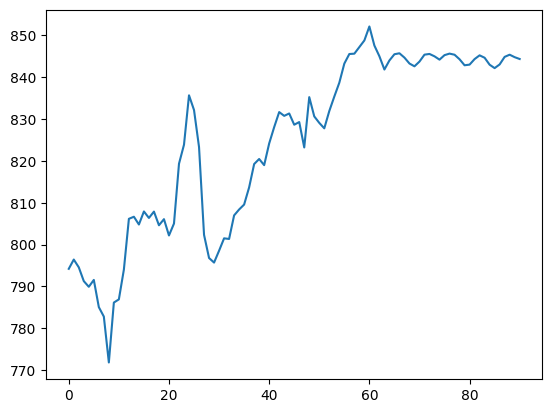

In [157]:
import matplotlib.pyplot as plt

seq = ds.values[:,1:]
seq = (seq - mean) / std
seq = seq.tolist()
N = len(seq)

for _ in range(30):
  L = len(seq)
  input_seq = torch.Tensor(seq[L-window_len:L])
  input_seq = input_seq.reshape((1, window_len, 5))
  pred = model(input_seq)
  pred = pred[0][-1].detach().numpy()
  pred = pred.tolist()
  seq.append(pred)

print(N, L)
plt.plot(list(range(len(seq))), [x[3] * std[3] + mean[3] for x in seq])
plt.show()